In [1]:
import MDAnalysis as mda
import prolif as plf

path = '/media/leandro/My Passport/GUSB/dockings/dockings/project_gromacs/PMelanin/PM_estol/data_estradiol_PMelanin/'
u = mda.Universe(path + "md.tpr", path + "md_center.xtc")

lig = u.select_atoms('resid 1273')
prot = u.select_atoms('protein')
fp = plf.Fingerprint()

fp.run(
    u.trajectory[:],
    lig,
    prot,
    n_jobs=1
)

df = fp.to_dataframe()
df.to_pickle(path + "prolif_df.pkl")

/home/leandro/anaconda3/lib/python3.12/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


  0%|          | 0/10001 [00:00<?, ?it/s]

/home/leandro/anaconda3/lib/python3.12/site-packages/MDAnalysis/converters/RDKitInferring.py:633: UserWarning: The standardization could not be completed within a reasonable number of iterations
  warnings.warn(


In [19]:
import pandas as pd

path = '/media/leandro/My Passport/GUSB/dockings/dockings/project_gromacs/PMelanin/PM_estol/data_estradiol_PMelanin/'
path2 = '/media/leandro/My Passport/GUSB/dockings/dockings/project_gromacs/PMelanin/data_gluestradiol_PMelanin/'
path3 = '/media/leandro/My Passport/GUSB/dockings/dockings/project_gromacs/PMelanin/PM_gluestrone/PM_gluestrone/data_gluestrona_PMelanin/'
df = pd.read_pickle(path + 'prolif_df.pkl')
df_2 = pd.read_pickle(path2 + 'prolif_df.pkl')
df3 = pd.read_pickle(path3 + 'prolif_df.pkl')

In [20]:
occupancy = df.mean().sort_values(ascending=False)
occupancy2 = df_2.mean().sort_values(ascending=False)
occupancy3 = df3.mean().sort_values(ascending=False)

In [21]:
occ = df.mean() * 100

res_occ = {}

for col, value in occ.items():
    lig, prot, interaction = col

    if prot not in res_occ:
        res_occ[prot] = []

    res_occ[prot].append(value)

res_occ = {
    res: max(vals)
    for res, vals in res_occ.items()
}
res_occ_df = (
    pd.DataFrame.from_dict(
        res_occ,
        orient="index",
        columns=["occupancy"]
    )
    .sort_values("occupancy", ascending=False)
)

print(res_occ_df.head(20))

           occupancy
GLU734.A   24.247575
CYS1197.A  20.037996
TYR703.A   15.878412
ASP396.A   12.508749
GLU661.A   12.278772
HIS590.A   11.348865
ASN660.A   11.058894
MET702.A    9.229077
PHE805.A    7.579242
SER1196.A   6.429357
TRP765.A    4.739526
ARG710.A    4.739526
GLN802.A    4.409559
LYS1195.A   2.239776
GLY711.A    1.569843
ARG690.A    1.499850
THR714.A    1.439856
TRP620.A    1.319868
MET1005.A   1.299870
ASN1003.A   0.969903


In [22]:
occ_2 = df_2.mean() * 100

res_occ_2 = {}

for col, value in occ_2.items():
    lig, prot, interaction = col

    if prot not in res_occ_2:
        res_occ_2[prot] = []

    res_occ_2[prot].append(value)

res_occ_2 = {
    res: max(vals)
    for res, vals in res_occ_2.items()
}
res_occ_df_2 = (
    pd.DataFrame.from_dict(
        res_occ_2,
        orient="index",
        columns=["occupancy"]
    )
    .sort_values("occupancy", ascending=False)
)

print(res_occ_df_2.head(20))

           occupancy
HIS590.A    4.249575
ASN660.A    3.039696
MET702.A    2.079792
GLU686.A    2.029797
CYS1197.A   2.009799
ARG710.A    1.479852
GLU734.A    1.069893
ASP396.A    1.049895
TRP765.A    0.879912
ASN1069.A   0.409959
THR714.A    0.369963
ASN294.A    0.349965
TYR703.A    0.309969
ARG690.A    0.269973
LYS1209.A   0.199980
ASP58.A     0.199980
VAL295.A    0.169983
ARG57.A     0.159984
HIS708.A    0.139986
SER709.A    0.119988


In [23]:
occ_3 = df3.mean() * 100

res_occ_3 = {}

for col, value in occ_3.items():
    lig, prot, interaction = col

    if prot not in res_occ_3:
        res_occ_3[prot] = []

    res_occ_3[prot].append(value)

res_occ_3 = {
    res: max(vals)
    for res, vals in res_occ_3.items()
}
res_occ_df_3 = (
    pd.DataFrame.from_dict(
        res_occ_3,
        orient="index",
        columns=["occupancy"]
    )
    .sort_values("occupancy", ascending=False)
)

print(res_occ_df_3.head(20))

            occupancy
ASN1194.A  100.000000
GLY1193.A  100.000000
LYS1195.A   99.930007
ASN741.A    99.370063
ASP707.A    98.960104
GLY744.A    96.080392
MET739.A    94.570543
TRP765.A    93.190681
ALA742.A    90.960904
ALA738.A    87.921208
VAL743.A    82.081792
ASN1001.A   73.752625
HIS737.A    66.903310
HIS708.A    55.334467
LEU1192.A   47.005299
ASN745.A    44.055594
TYR749.A    37.466253
VAL706.A    31.336866
ALA736.A    29.557044
GLY740.A    23.167683


In [24]:
import pandas as pd
import re

# =====================================================
# Funciones auxiliares
# =====================================================

def extraer_numero(idx):
    """Extrae el número de un índice como 'PRO226.A' -> 226"""
    match = re.search(r'\d+', str(idx))
    return int(match.group()) if match else None


def extraer_aminoacido(idx):
    """Extrae el aminoácido de un índice como 'PRO226.A' -> PRO"""
    match = re.match(r'([A-Za-z]+)', str(idx))
    return match.group(1) if match else None


# =====================================================
# Función principal
# =====================================================

def unir_tablas_con_corrimiento(tablas_dict, corrimientos_dict):

    tablas_preparadas = {}

    # -------------------------
    # Preparar cada tabla
    # -------------------------
    for nombre, df in tablas_dict.items():

        corrimiento = corrimientos_dict.get(nombre, 0)

        df_temp = df.copy()

        numeros = [extraer_numero(idx) for idx in df_temp.index]
        aminoacidos = [extraer_aminoacido(idx) for idx in df_temp.index]

        df_temp["residuo_num"] = [
            n + corrimiento if n is not None else None
            for n in numeros
        ]

        df_temp["aa"] = aminoacidos
        df_temp["residuo_original"] = df_temp.index

        tablas_preparadas[nombre] = df_temp

    # -------------------------
    # Primera tabla
    # -------------------------
    nombres = list(tablas_preparadas.keys())

    df_merged = tablas_preparadas[nombres[0]][
        ["residuo_num", "aa", "residuo_original", "occupancy"]
    ].copy()

    df_merged.columns = [
        "residuo_num",
        "aa",
        f"residuo_{nombres[0]}",
        f"occupancy_{nombres[0]}"
    ]

    # -------------------------
    # Unir las demás tablas
    # -------------------------
    for nombre in nombres[1:]:

        df_temp = tablas_preparadas[nombre][
            ["residuo_num", "aa", "residuo_original", "occupancy"]
        ].copy()

        df_temp.columns = [
            "residuo_num",
            f"aa_{nombre}",
            f"residuo_{nombre}",
            f"occupancy_{nombre}"
        ]

        df_merged = pd.merge(
            df_merged,
            df_temp,
            on="residuo_num",
            how="outer"
        )

    # =====================================================
    # Completar automáticamente los aminoácidos faltantes
    # =====================================================

    columnas_aa = [c for c in df_merged.columns if c.startswith("aa")]

    for col in columnas_aa:
        df_merged["aa"] = df_merged["aa"].fillna(df_merged[col])

    # Eliminar columnas auxiliares aa_tablaX
    columnas_aux = [c for c in columnas_aa if c != "aa"]
    df_merged.drop(columns=columnas_aux, inplace=True)

    # =====================================================
    # Crear etiqueta para el gráfico
    # =====================================================

    df_merged["etiqueta"] = (
        df_merged["aa"].fillna("") +
        df_merged["residuo_num"].astype("Int64").astype(str)
    )

    # Ordenar por número de residuo
    df_merged.sort_values("residuo_num", inplace=True)
    df_merged.reset_index(drop=True, inplace=True)

    return df_merged


# =====================================================
# USO
# =====================================================

tablas = {
    "tabla1": res_occ_df,
    "tabla2": res_occ_df_2,
    "tabla3": res_occ_df_3,      # opcional
    # "tabla4": res_occ_df_4,    # si agregás más, no hace falta cambiar la función
}

corrimientos = {
    "tabla1": 0,
    "tabla2": 0,
    "tabla3": 0,
    # "tabla4": 223,
}

df_final = unir_tablas_con_corrimiento(tablas, corrimientos)

In [25]:
df_final

,residuo_num,aa,residuo_tabla1,occupancy_tabla1,residuo_tabla2,occupancy_tabla2,residuo_tabla3,occupancy_tabla3,etiqueta
0,57,ARG,NaN,NaN,ARG57.A,0.159984,NaN,NaN,ARG57
1,58,ASP,NaN,NaN,ASP58.A,0.199980,NaN,NaN,ASP58
2,104,ASP,NaN,NaN,ASP104.A,0.019998,NaN,NaN,ASP104
3,215,LYS,LYS215.A,0.019998,NaN,NaN,NaN,NaN,LYS215
4,242,THR,NaN,NaN,THR242.A,0.009999,NaN,NaN,THR242
...,...,...,...,...,...,...,...,...,...
98,1202,LEU,NaN,NaN,NaN,NaN,LEU1202.A,14.278572,LEU1202
99,1203,SER,NaN,NaN,SER1203.A,0.029997,NaN,NaN,SER1203
100,1204,LYS,NaN,NaN,NaN,NaN,LYS1204.A,5.899410,LYS1204
101,1205,TYR,NaN,NaN,NaN,NaN,TYR1205.A,0.679932,TYR1205


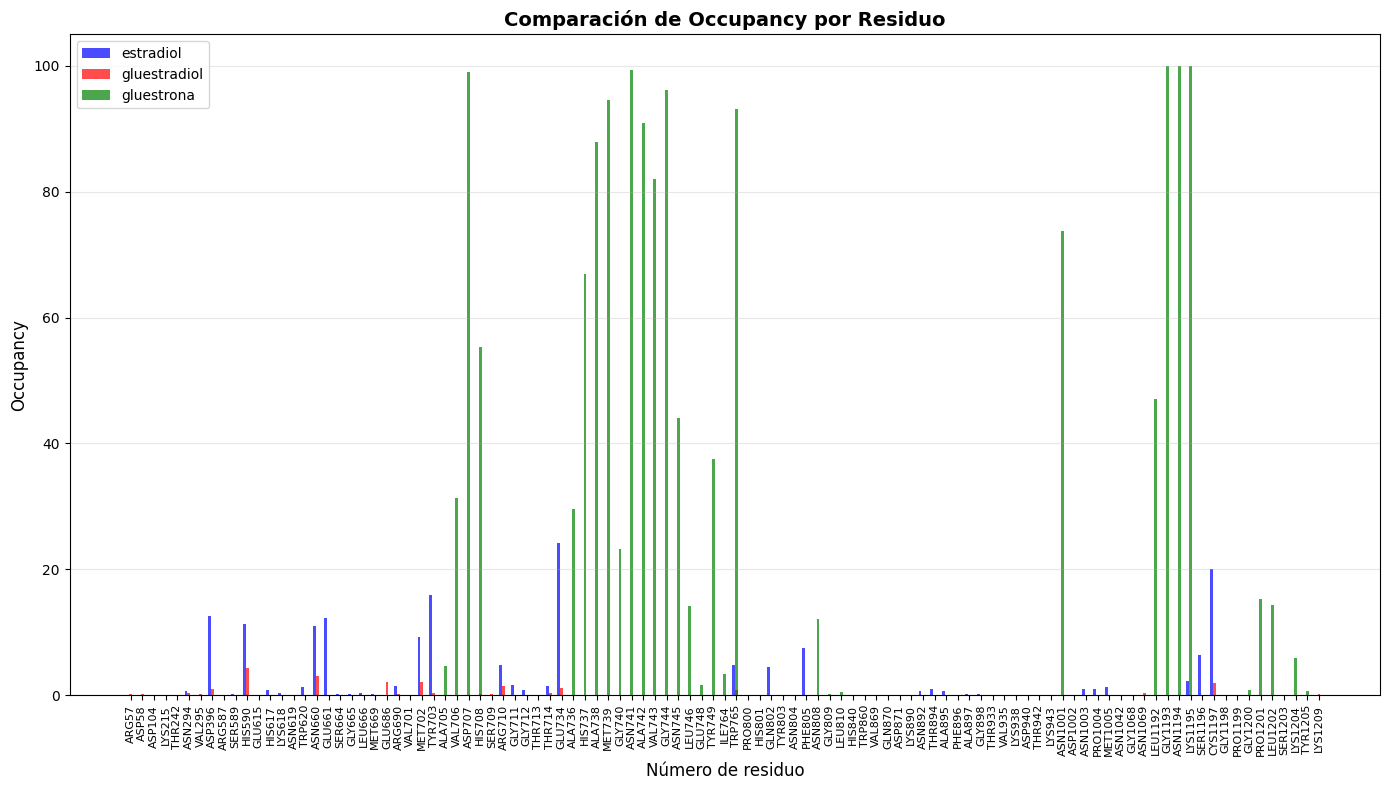

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar los datos para graficar
# Asumiendo que tienes df_final del paso anterior

# Crear figura
fig, ax = plt.subplots(figsize=(14, 8))

# Configurar posición de barras
x = np.arange(len(df_final))  # Posiciones en el eje X
width = 0.25  # Ancho de las barras

# Crear barras para cada tabla
bars1 = ax.bar(x - width, df_final['occupancy_tabla1'], width, 
               label='estradiol', color='blue', alpha=0.7)
bars2 = ax.bar(x, df_final['occupancy_tabla2'], width, 
               label='gluestradiol', color='red', alpha=0.7)
bars3 = ax.bar(x, df_final['occupancy_tabla3'], width, 
               label='gluestrona', color='green', alpha=0.7)
# Personalizar el gráfico
ax.set_xlabel('Número de residuo', fontsize=12)
ax.set_ylabel('Occupancy', fontsize=12)
ax.set_title('Comparación de Occupancy por Residuo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_final['etiqueta'], rotation=90, fontsize=8)
ax.legend()

# Añadir grid
ax.grid(True, alpha=0.3, axis='y')

# Ajustar layout
plt.tight_layout()
plt.savefig('/media/leandro/My Passport/GUSB/dockings/dockings/project_gromacs/Comparación de Ocupancia por residuo-PMelaningogenic.png')
plt.show()

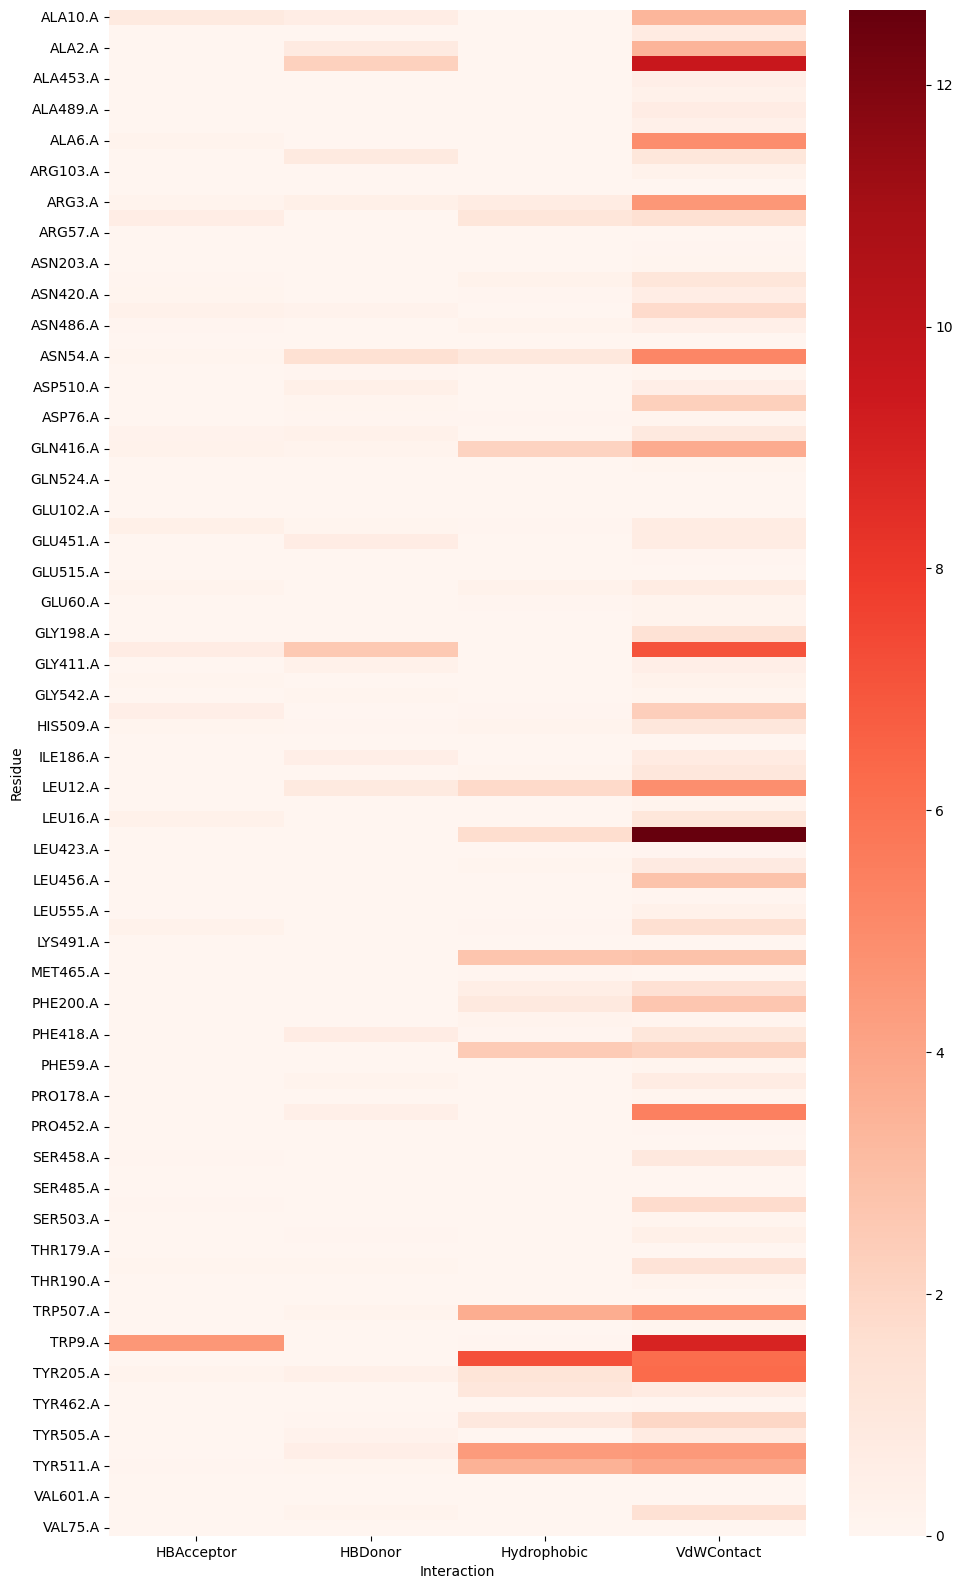

In [10]:
import seaborn as sns

records = []

for col, value in occ.items():

    lig, prot, interaction = col

    records.append([
        prot,
        interaction,
        value
    ])

heat_df = pd.DataFrame(
    records,
    columns=["Residue", "Interaction", "Occupancy"]
)
pivot = heat_df.pivot_table(
    index="Residue",
    columns="Interaction",
    values="Occupancy",
    fill_value=0
)

plt.figure(figsize=(10,16))

sns.heatmap(
    pivot,
    cmap="Reds"
)

plt.tight_layout()
plt.show()

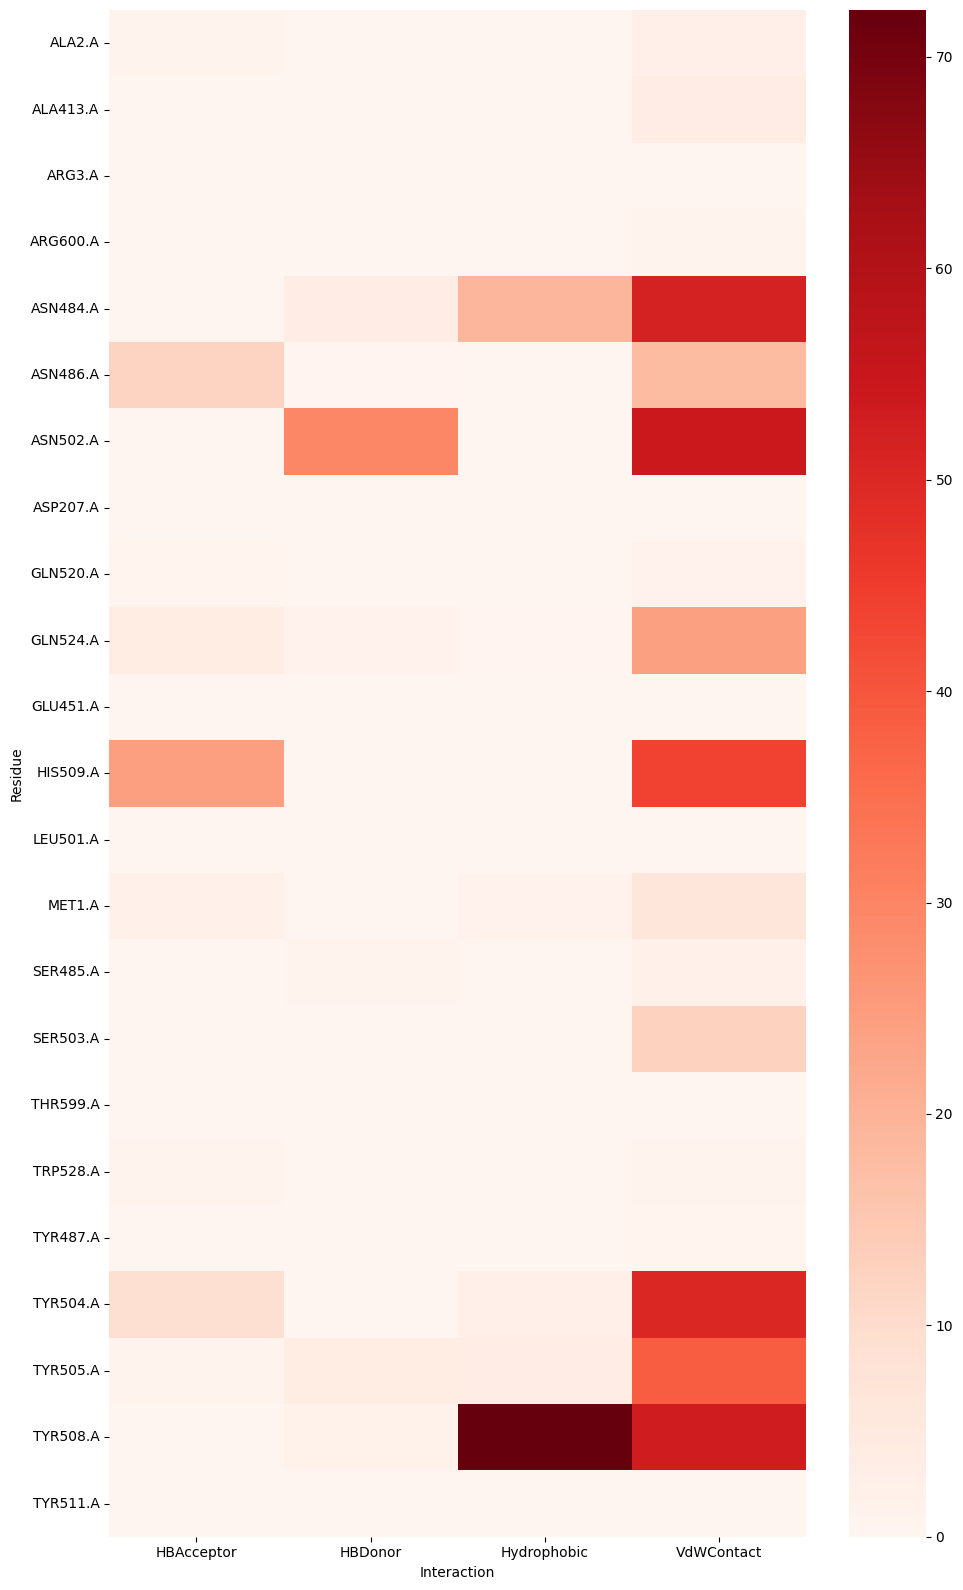

In [11]:
import seaborn as sns

records = []

for col, value in occ_2.items():

    lig, prot, interaction = col

    records.append([
        prot,
        interaction,
        value
    ])

heat_df = pd.DataFrame(
    records,
    columns=["Residue", "Interaction", "Occupancy"]
)
pivot = heat_df.pivot_table(
    index="Residue",
    columns="Interaction",
    values="Occupancy",
    fill_value=0
)

plt.figure(figsize=(10,16))

sns.heatmap(
    pivot,
    cmap="Reds"
)

plt.tight_layout()
plt.show()